# 08 – Visualizing the CARMENES Mask on a Combined Spectrum

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
import os
import matplotlib.patches as patches
from matplotlib.cm import get_cmap

Paths:

In [23]:
fits_root = "../../aumicAE"
mask_path = "../../aumicAE/data/masks/CARM_VIS_M15.mas"

Load mask:

In [24]:
mask_df = pd.read_csv(mask_path, delim_whitespace=True, comment="#", header=None,
                      names=["lambda", "weight", "element"])

/tmp/ipykernel_12553/2117432136.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  mask_df = pd.read_csv(mask_path, delim_whitespace=True, comment="#", header=None,


Load file list:

In [25]:
with open("../../aumicAE/data/carvis_visA/vis_a_files.txt", "r") as f:
    vis_a_files = [os.path.join(fits_root, line.strip().lstrip("../")) for line in f if line.strip()]

Get the relevant Extensions for the first spectrum:

In [26]:
file = vis_a_files[0]
with fits.open(file) as hdul:
    print([hdu.name for hdu in hdul])

['PRIMARY', 'SPEC', 'CONT', 'SIG', 'WAVE']


In [27]:
file = vis_a_files[0]
with fits.open(file) as hdul:
    wave = hdul["WAVE"].data
    flux = hdul["SPEC"].data
    cont = hdul["CONT"].data  # continuum ≈ blaze

n_orders = cont.shape[0]
pixels = cont.shape[1]

Combine orders (simple concat for visualization):

In [28]:
wave_all = np.concatenate(wave)
flux_all = np.concatenate(flux)

Remove NaNs and infinities before plotting:

In [29]:
flux_clean = np.nan_to_num(flux_all, nan=0.0, posinf=np.nanmax(flux_all[np.isfinite(flux_all)]), neginf=0.0)
ymax = np.percentile(flux_clean, 99)

### Plot Full Spectrum with Mask Lines

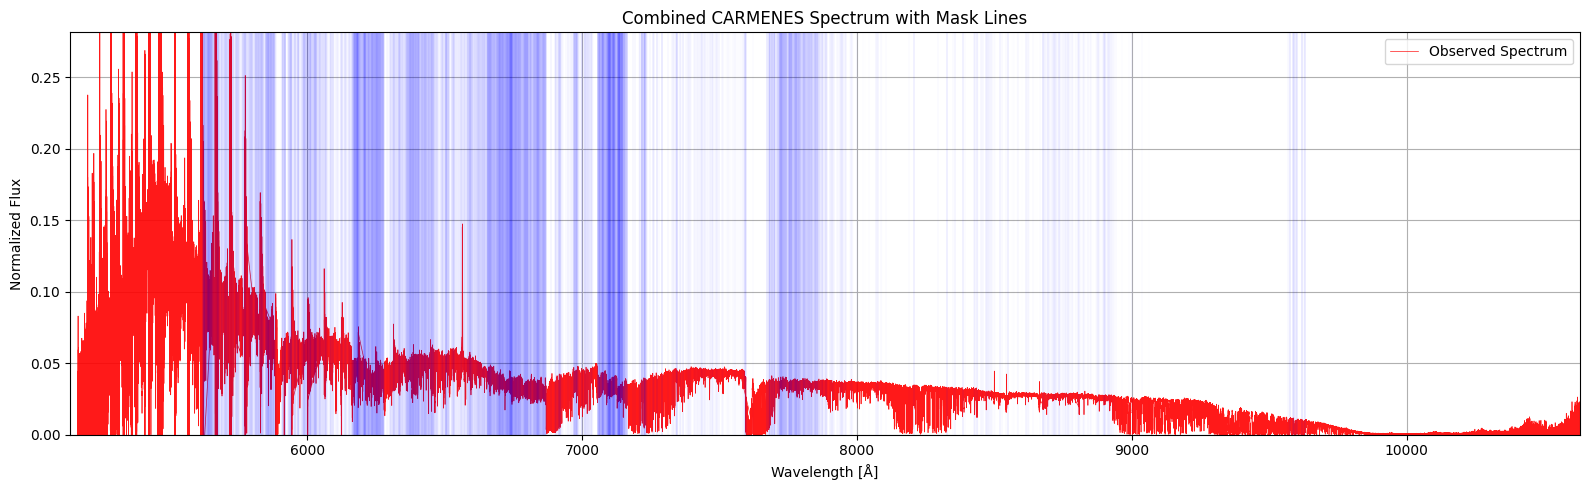

In [30]:
plt.figure(figsize=(16, 5))
plt.plot(wave_all, flux_all, lw=0.5, color='red', alpha=0.9, label='Observed Spectrum')

# Overlay mask lines
for _, row in mask_df.iterrows():
    plt.axvline(row["lambda"], color='blue', alpha=0.75, lw=row["weight"])

plt.title("Combined CARMENES Spectrum with Mask Lines")
plt.xlabel("Wavelength [Å]")
plt.ylabel("Normalized Flux")
plt.xlim(wave_all[0], wave_all[-1])
plt.ylim(0, np.percentile(flux_clean, 99.9))
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## SNR / Cont vs. Wavelength

I visualize the blaze function across all orders to understand how the signal-to-noise (or throughput) varies with wavelength.

This helps identify which regions of the spectrum have poor signal, e.g., the blue or red ends.

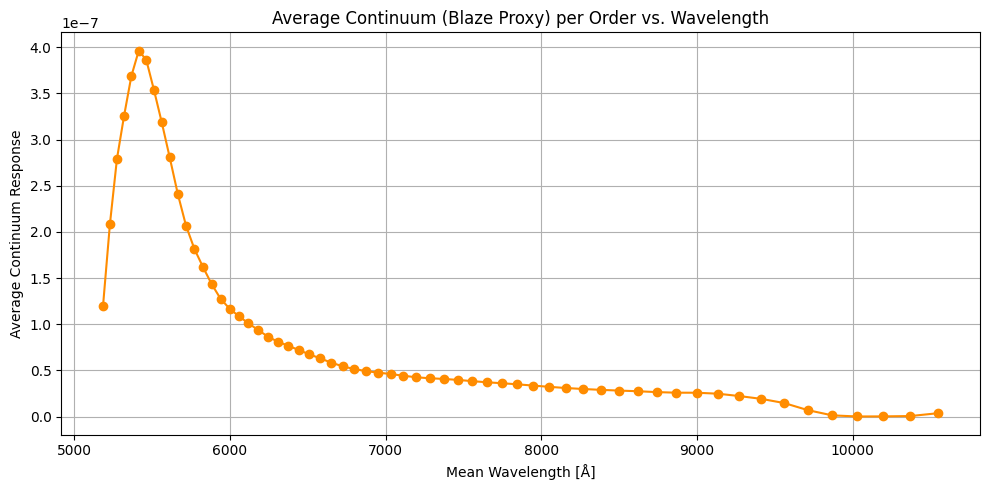

In [31]:
mean_cont_per_order = cont.mean(axis=1)
mean_wavelength_per_order = wave.mean(axis=1)

plt.figure(figsize=(10, 5))
plt.plot(mean_wavelength_per_order, mean_cont_per_order, marker='o', color='darkorange')
plt.title("Average Continuum (Blaze Proxy) per Order vs. Wavelength")
plt.xlabel("Mean Wavelength [Å]")
plt.ylabel("Average Continuum Response")
plt.grid(True)
plt.tight_layout()
plt.show()

## Crop and Re-Plot the Spectrum

Here I visualize only the usable wavelength range (~5600–8900 Å), with vertical lines from the mask.

This excludes both the noisy blue region and the uncertain far-red.

In [32]:
# flatten a spectrum
wave_flat = np.concatenate(wave)
flux_flat = np.concatenate(flux)
flux_flat = np.nan_to_num(flux_flat, nan=0.0, posinf=0.0, neginf=0.0)

# Crop to clean region
mask = (wave_flat >= 5600) & (wave_flat <= 8900)
wave_crop = wave_flat[mask]
flux_crop = flux_flat[mask]
mask_lines_crop = mask_df[(mask_df["lambda"] >= 5600) & (mask_df["lambda"] <= 8900)]

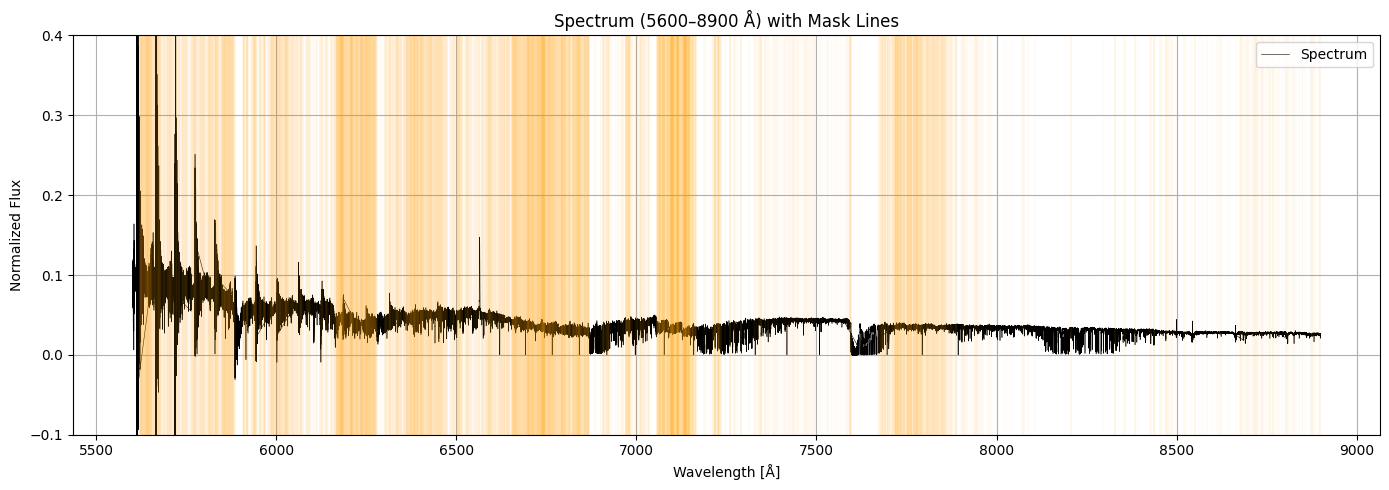

In [33]:
plt.figure(figsize=(14, 5))
plt.plot(wave_crop, flux_crop, lw=0.4, color='black', label="Spectrum")

for _, row in mask_lines_crop.iterrows():
    color = 'red' if row["weight"] > 0.3 else 'orange'
    plt.axvline(row["lambda"], color=color, alpha=0.6, lw=row["weight"] * 2)

plt.title("Spectrum (5600–8900 Å) with Mask Lines")
plt.xlabel("Wavelength [Å]")
plt.ylabel("Normalized Flux")
plt.ylim(-0.1, 0.4)  # clip the spikes on the left
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## The spectrum beyond 9000 Å

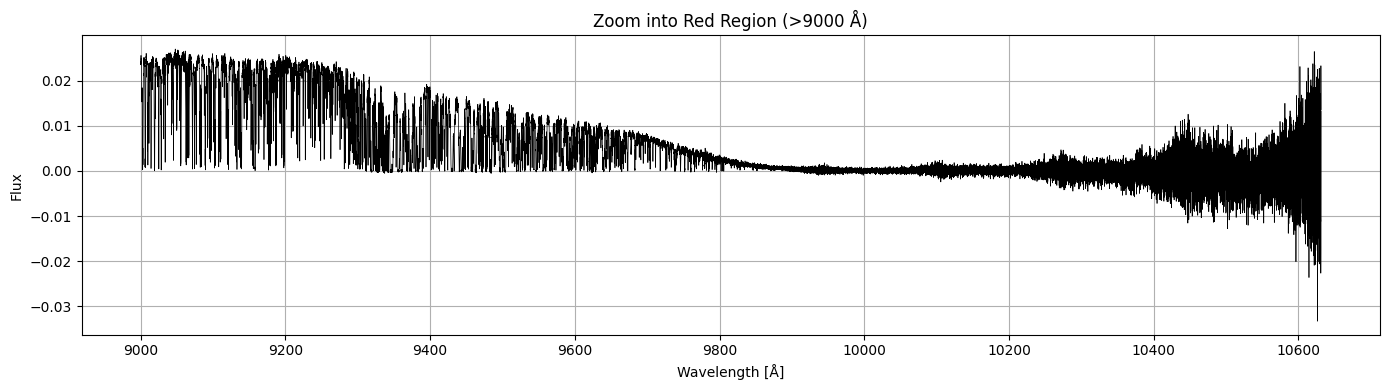

In [34]:
# Crop the long-wavelength (reddest) region
mask_red = (wave_flat >= 9000) & (wave_flat <= wave_flat.max())
wave_red = wave_flat[mask_red]
flux_red = flux_flat[mask_red]

plt.figure(figsize=(14, 4))
plt.plot(wave_red, flux_red, lw=0.5, color='black')
plt.title("Zoom into Red Region (>9000 Å)")
plt.xlabel("Wavelength [Å]")
plt.ylabel("Flux")
plt.grid(True)
plt.tight_layout()
plt.show()

## Overlay telluric regions

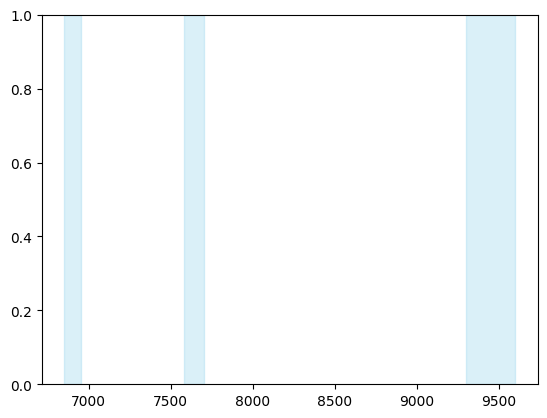

In [35]:
telluric_bands = [
    (9300, 9600),  # strong water band
    (6850, 6950),  # O₂ B-band
    (7580, 7700),  # O₂ A-band
]

for start, end in telluric_bands:
    plt.axvspan(start, end, color='skyblue', alpha=0.3, label="Telluric Band")

## Identifying relevant orders

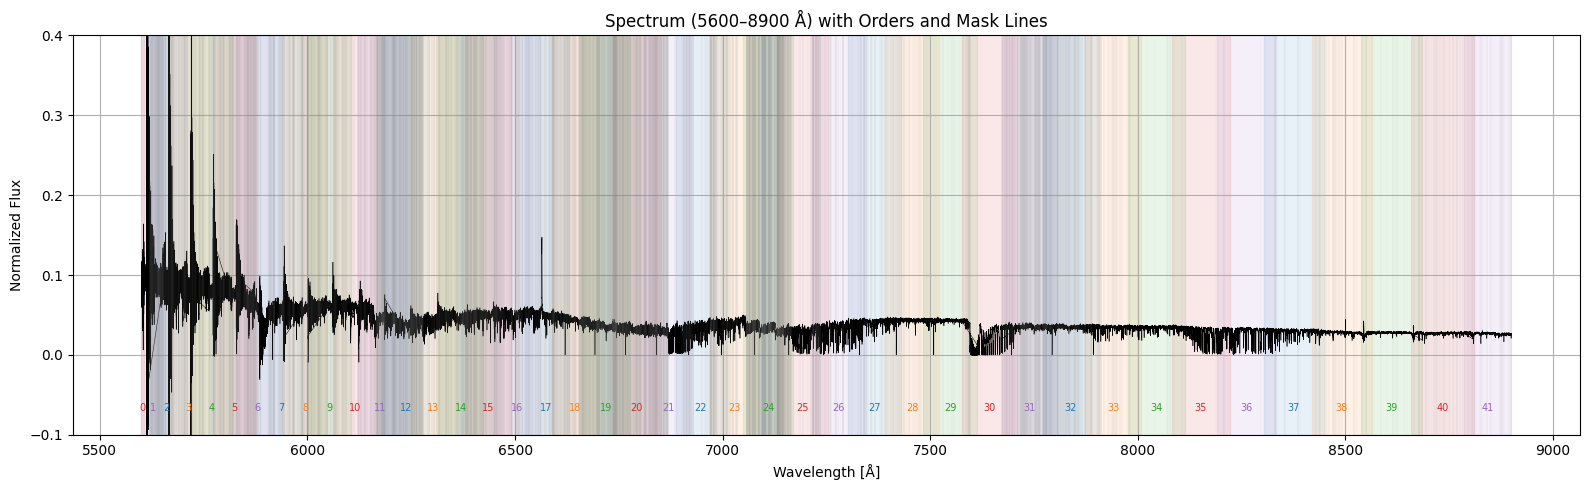

In [36]:
# Define 5 cycling colors
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# Flatten and crop
wave_flat = np.concatenate(wave)
flux_flat = np.concatenate(flux)
flux_flat = np.nan_to_num(flux_flat, nan=0.0, posinf=0.0, neginf=0.0)

mask = (wave_flat >= 5600) & (wave_flat <= 8900)
wave_crop = wave_flat[mask]
flux_crop = flux_flat[mask]
mask_lines_crop = mask_df[(mask_df["lambda"] >= 5600) & (mask_df["lambda"] <= 8900)]

# Order edges and colors
order_boundaries = []
wave_order_means = []
order_colors = []

for i in range(n_orders):
    w = wave[i]
    if w[-1] < 5600 or w[0] > 8900:
        continue
    left = max(w[0], 5600)
    right = min(w[-1], 8900)
    center = (left + right) / 2
    order_boundaries.append((left, right))
    wave_order_means.append(center)
    order_colors.append(colors[i % 5])

# Plot
plt.figure(figsize=(16, 5))
plt.plot(wave_crop, flux_crop, lw=0.4, color='black', label="Spectrum")

# Shaded order backgrounds
for i, (left, right) in enumerate(order_boundaries):
    plt.axvspan(left, right, color=order_colors[i], alpha=0.1)

# Mask lines
for _, row in mask_lines_crop.iterrows():
    color = 'red' if row["weight"] > 0.3 else 'grey'
    plt.axvline(row["lambda"], color=color, alpha=0.6, lw=row["weight"] * 2)

# Order numbers as x-axis annotation
for i, (center, col) in enumerate(zip(wave_order_means, order_colors)):
    plt.text(center, -0.06, f"{i}", color=col, ha='center', va='top', fontsize=7)

plt.title("Spectrum (5600–8900 Å) with Orders and Mask Lines")
plt.xlabel("Wavelength [Å]")
plt.ylabel("Normalized Flux")
plt.ylim(-0.1, 0.4)
plt.grid(True)
plt.tight_layout()
plt.show()


/tmp/ipykernel_12553/3006186756.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('tab20', n_orders)


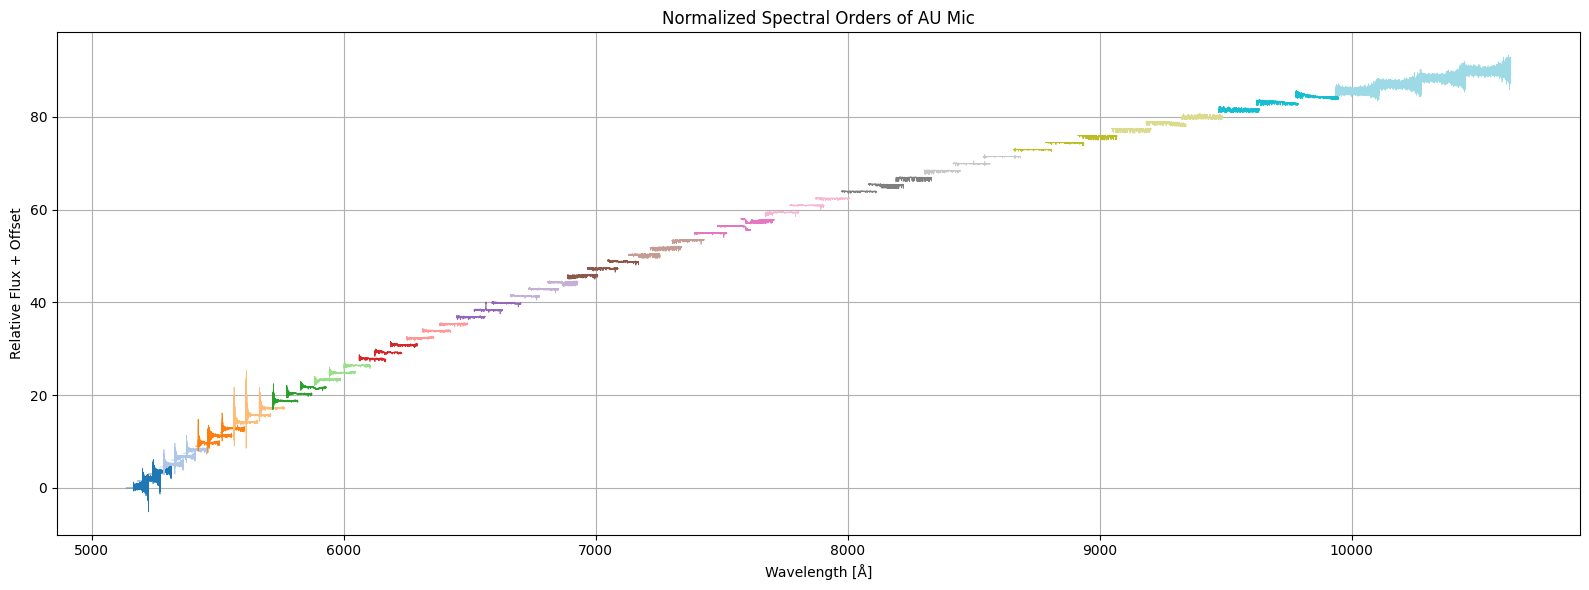

In [37]:
cmap = get_cmap('tab20', n_orders)

plt.figure(figsize=(16, 6))
for i in range(n_orders):
    wave_i = wave[i]
    flux_i = flux[i]
    
    # Normalize flux to its 95th percentile (avoid spikes)
    flux_i = np.nan_to_num(flux_i, nan=0.0, posinf=0.0, neginf=0.0)
    flux_norm = flux_i / np.percentile(flux_i, 95)

    plt.plot(wave_i, flux_norm + i * 1.5, color=cmap(i), lw=0.5, label=f"Order {i}")

plt.title("Normalized Spectral Orders of AU Mic")
plt.xlabel("Wavelength [Å]")
plt.ylabel("Relative Flux + Offset")
plt.grid(True)
plt.tight_layout()
plt.show()